<h1> Image Detection Using CV2 </h1>
<h4 style="color:#555; margin-top:-8px;">
</h4>

<hr style="border:1px solid #ddd;">

In [4]:
import cv2
import matplotlib.pyplot as plt

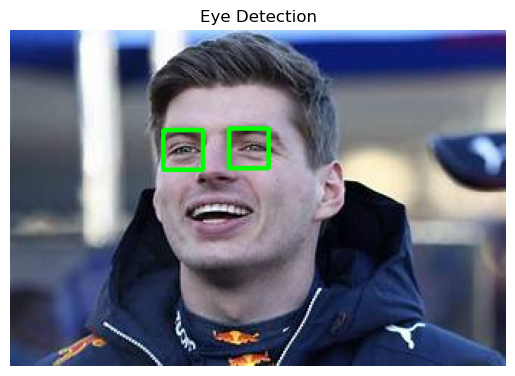

In [8]:
img = cv2.imread("img/OIP.jfif")
eyes = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Detect eyes
detected_eyes = eyes.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
# Draw rectangles
for (x, y, w, h) in detected_eyes:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
# Show result
# Convert BGR → RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Display image
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Eye Detection")
plt.show()

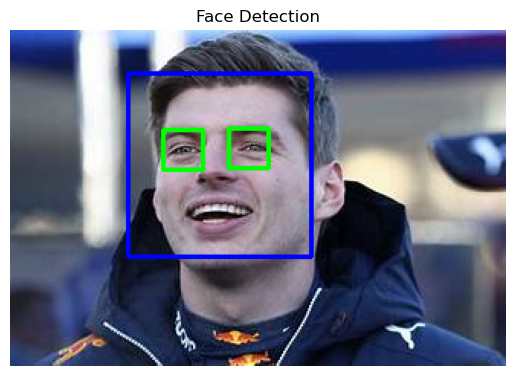

In [14]:
img = cv2.imread("img/OIP.jfif")
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Detect faces first
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
# Detect eyes
detected_eyes = eyes.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
# Draw rectangles
for (x, y, w, h) in detected_eyes:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
for (x, y, w, h) in faces:
    # Draw face rectangle
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    roi_gray = gray[y:y + h, x:x + w]
    roi_color = img[y:y + h, x:x + w]
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Face Detection")
plt.show()

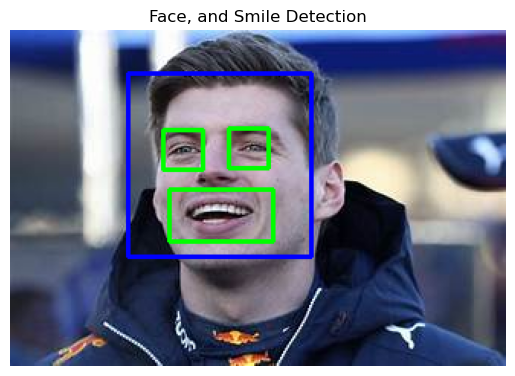

In [15]:
img = cv2.imread("img/OIP.jfif")

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_smile.xml")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
for (x, y, w, h) in detected_eyes:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    roi_gray = gray[y:y + h, x:x + w]
    smiles = smile_cascade.detectMultiScale(roi_gray,scaleFactor=1.3,minNeighbors=15,minSize=(20, 20))
    for (sx, sy, sw, sh) in smiles:
      cv2.rectangle(img, (x + sx, y + sy),(x + sx + sw, y + sy + sh), (0, 255, 0), 2)

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Face, Eye and Smile Detection")
plt.show()

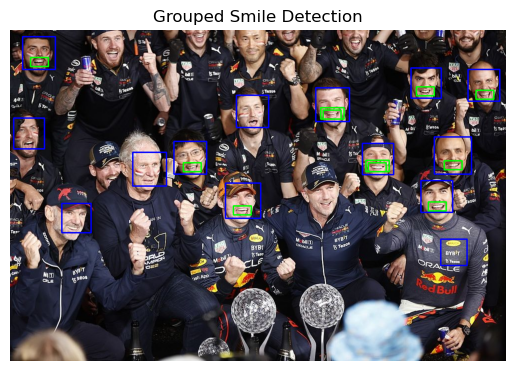

14 number of faces detected


In [19]:
img = cv2.imread("img/2.jpg")

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_smile.xml")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
count = 0 

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    roi_gray = gray[y:y + h, x:x + w]
    smiles = smile_cascade.detectMultiScale(roi_gray,scaleFactor=1.3,minNeighbors=8,minSize=(15, 15))
    for (sx, sy, sw, sh) in smiles:
      cv2.rectangle(img, (x + sx, y + sy),(x + sx + sw, y + sy + sh), (0, 255, 0), 2)
    count +=1 
# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Grouped Smile Detection")
plt.show() 
print(f'{count} number of faces detected') 

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
As you can see Haarcascade doesn't detect all of the faces. This is the limitation of the xml. Also it detects a wrong face as a face. 

In [20]:
# Find a dataset which can be used for face detection 